In [13]:
import pandas as pd
import numpy as np
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [14]:
df1=pd.read_csv('Energy_Consumption.csv')
df1

,Household_ID,Avg_Daily_Usage_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh,Num_Occupants,Temp_C,Appliance_Count,Income_Level,Smart_Meter,House_Size_sqft,AC_Usage_Hours,Lighting_Type,Renewable_Source,Work_From_Home,Consumption_Class
0,H001,9.367182,5.736213,4.406728,2,26.858403,9,Medium,No,2520.0,3.740278,Incandescent,Yes,2,Medium
1,H002,19.162143,4.520723,9.044712,6,17.848916,3,Medium,No,3577.0,0.037691,CFL,No,3,High
2,H003,15.443897,2.821457,13.348296,4,27.150388,6,Low,No,692.0,2.090921,Incandescent,No,2,High
3,H004,13.177194,6.603463,11.518924,5,NaN,4,Low,Yes,838.0,10.504867,CFL,Yes,3,Medium
4,H005,5.652317,5.635484,12.485295,5,28.019204,4,High,Yes,804.0,5.300958,Incandescent,No,3,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,H496,9.006988,1.186866,10.686766,2,32.960731,4,High,No,NaN,0.282390,LED,Yes,2,Medium
496,H497,12.922154,7.379852,10.053375,2,38.850828,11,Medium,No,1889.0,5.155474,LED,No,0,Medium
497,H498,4.321489,1.526140,8.025423,5,33.034836,11,Low,Yes,2047.0,3.347257,LED,No,2,Low
498,H499,19.564712,7.626780,6.937215,4,NaN,8,High,Yes,3799.0,1.550093,Incandescent,Yes,3,High


# Exploratory Data Analysis

In [3]:
df1.head()

,Household_ID,Avg_Daily_Usage_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh,Num_Occupants,Temp_C,Appliance_Count,Income_Level,Smart_Meter,House_Size_sqft,AC_Usage_Hours,Lighting_Type,Renewable_Source,Work_From_Home,Consumption_Class
0,H001,9.367182,5.736213,4.406728,2,26.858403,9,Medium,No,2520.0,3.740278,Incandescent,Yes,2,Medium
1,H002,19.162143,4.520723,9.044712,6,17.848916,3,Medium,No,3577.0,0.037691,CFL,No,3,High
2,H003,15.443897,2.821457,13.348296,4,27.150388,6,Low,No,692.0,2.090921,Incandescent,No,2,High
3,H004,13.177194,6.603463,11.518924,5,NaN,4,Low,Yes,838.0,10.504867,CFL,Yes,3,Medium
4,H005,5.652317,5.635484,12.485295,5,28.019204,4,High,Yes,804.0,5.300958,Incandescent,No,3,Low


In [13]:
df1.tail()

,Household_ID,Avg_Daily_Usage_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh,Num_Occupants,Temp_C,Appliance_Count,Income_Level,Smart_Meter,House_Size_sqft,AC_Usage_Hours,Lighting_Type,Renewable_Source,Work_From_Home,Consumption_Class
495,H496,9.006988,1.186866,10.686766,2,32.960731,4,High,No,NaN,0.282390,LED,Yes,2,Medium
496,H497,12.922154,7.379852,10.053375,2,38.850828,11,Medium,No,1889.0,5.155474,LED,No,0,Medium
497,H498,4.321489,1.526140,8.025423,5,33.034836,11,Low,Yes,2047.0,3.347257,LED,No,2,Low
498,H499,19.564712,7.626780,6.937215,4,NaN,8,High,Yes,3799.0,1.550093,Incandescent,Yes,3,High
499,H500,19.765583,3.845043,13.223337,4,15.052596,13,High,No,2885.0,1.194558,Incandescent,No,1,High


In [14]:
df1.isna().sum()

Household_ID            0
Avg_Daily_Usage_kWh     0
Peak_Hour_Usage_kWh     0
Off_Peak_Usage_kWh      0
Num_Occupants           0
Temp_C                 27
Appliance_Count         0
Income_Level            0
Smart_Meter             0
House_Size_sqft         9
AC_Usage_Hours          0
Lighting_Type           0
Renewable_Source        0
Work_From_Home          0
Consumption_Class       0
dtype: int64

In [15]:
df1.duplicated().any()

np.False_

In [16]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Household_ID         500 non-null    object 
 1   Avg_Daily_Usage_kWh  500 non-null    float64
 2   Peak_Hour_Usage_kWh  500 non-null    float64
 3   Off_Peak_Usage_kWh   500 non-null    float64
 4   Num_Occupants        500 non-null    int64  
 5   Temp_C               473 non-null    float64
 6   Appliance_Count      500 non-null    int64  
 7   Income_Level         500 non-null    object 
 8   Smart_Meter          500 non-null    object 
 9   House_Size_sqft      491 non-null    float64
 10  AC_Usage_Hours       500 non-null    float64
 11  Lighting_Type        500 non-null    object 
 12  Renewable_Source     500 non-null    object 
 13  Work_From_Home       500 non-null    int64  
 14  Consumption_Class    500 non-null    object 
dtypes: float64(6), int64(3), object(6)
memor

In [17]:
df1.describe()

,Avg_Daily_Usage_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh,Num_Occupants,Temp_C,Appliance_Count,House_Size_sqft,AC_Usage_Hours,Work_From_Home
count,500.000000,500.000000,500.000000,500.000000,473.000000,500.000000,491.000000,500.000000,500.000000
mean,11.475549,4.114635,8.728256,3.560000,27.323422,8.260000,2349.014257,5.840858,1.448000
std,5.077703,2.141201,3.863508,1.684064,7.276299,3.541396,1002.969966,3.437336,1.085196
min,3.086047,0.534740,2.064220,1.000000,15.004710,3.000000,602.000000,0.037691,0.000000
25%,7.101755,2.218244,5.135965,2.000000,20.819079,5.000000,1499.000000,2.877332,1.000000
50%,11.723784,4.038662,9.016598,4.000000,27.209366,8.000000,2428.000000,5.760474,1.000000
75%,15.854123,5.947526,12.105469,5.000000,33.648130,11.000000,3220.500000,8.850966,2.000000
max,19.880402,7.997883,14.992378,6.000000,39.926954,14.000000,3989.000000,11.971474,3.000000


In [4]:
df1['Lighting_Type'].value_counts()

Lighting_Type
Incandescent    175
CFL             170
LED             155
Name: count, dtype: int64

In [19]:
df1

,Household_ID,Avg_Daily_Usage_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh,Num_Occupants,Temp_C,Appliance_Count,Income_Level,Smart_Meter,House_Size_sqft,AC_Usage_Hours,Lighting_Type,Renewable_Source,Work_From_Home,Consumption_Class
0,H001,9.367182,5.736213,4.406728,2,26.858403,9,Medium,No,2520.0,3.740278,Incandescent,Yes,2,Medium
1,H002,19.162143,4.520723,9.044712,6,17.848916,3,Medium,No,3577.0,0.037691,CFL,No,3,High
2,H003,15.443897,2.821457,13.348296,4,27.150388,6,Low,No,692.0,2.090921,Incandescent,No,2,High
3,H004,13.177194,6.603463,11.518924,5,NaN,4,Low,Yes,838.0,10.504867,CFL,Yes,3,Medium
4,H005,5.652317,5.635484,12.485295,5,28.019204,4,High,Yes,804.0,5.300958,Incandescent,No,3,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,H496,9.006988,1.186866,10.686766,2,32.960731,4,High,No,NaN,0.282390,LED,Yes,2,Medium
496,H497,12.922154,7.379852,10.053375,2,38.850828,11,Medium,No,1889.0,5.155474,LED,No,0,Medium
497,H498,4.321489,1.526140,8.025423,5,33.034836,11,Low,Yes,2047.0,3.347257,LED,No,2,Low
498,H499,19.564712,7.626780,6.937215,4,NaN,8,High,Yes,3799.0,1.550093,Incandescent,Yes,3,High


In [5]:
df1.columns = df1.columns.str.strip()
df1

,Household_ID,Avg_Daily_Usage_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh,Num_Occupants,Temp_C,Appliance_Count,Income_Level,Smart_Meter,House_Size_sqft,AC_Usage_Hours,Lighting_Type,Renewable_Source,Work_From_Home,Consumption_Class
0,H001,9.367182,5.736213,4.406728,2,26.858403,9,Medium,No,2520.0,3.740278,Incandescent,Yes,2,Medium
1,H002,19.162143,4.520723,9.044712,6,17.848916,3,Medium,No,3577.0,0.037691,CFL,No,3,High
2,H003,15.443897,2.821457,13.348296,4,27.150388,6,Low,No,692.0,2.090921,Incandescent,No,2,High
3,H004,13.177194,6.603463,11.518924,5,NaN,4,Low,Yes,838.0,10.504867,CFL,Yes,3,Medium
4,H005,5.652317,5.635484,12.485295,5,28.019204,4,High,Yes,804.0,5.300958,Incandescent,No,3,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,H496,9.006988,1.186866,10.686766,2,32.960731,4,High,No,NaN,0.282390,LED,Yes,2,Medium
496,H497,12.922154,7.379852,10.053375,2,38.850828,11,Medium,No,1889.0,5.155474,LED,No,0,Medium
497,H498,4.321489,1.526140,8.025423,5,33.034836,11,Low,Yes,2047.0,3.347257,LED,No,2,Low
498,H499,19.564712,7.626780,6.937215,4,NaN,8,High,Yes,3799.0,1.550093,Incandescent,Yes,3,High


In [15]:

df = df1.drop(['Household_ID'], axis=1)
print(df.head())



   Avg_Daily_Usage_kWh  Peak_Hour_Usage_kWh  Off_Peak_Usage_kWh  \
0             9.367182             5.736213            4.406728   
1            19.162143             4.520723            9.044712   
2            15.443897             2.821457           13.348296   
3            13.177194             6.603463           11.518924   
4             5.652317             5.635484           12.485295   

   Num_Occupants     Temp_C  Appliance_Count Income_Level Smart_Meter  \
0              2  26.858403                9       Medium          No   
1              6  17.848916                3       Medium          No   
2              4  27.150388                6          Low          No   
3              5        NaN                4          Low         Yes   
4              5  28.019204                4         High         Yes   

   House_Size_sqft  AC_Usage_Hours Lighting_Type Renewable_Source  \
0           2520.0        3.740278  Incandescent              Yes   
1           3577.0  

In [22]:
df['House_Size_sqft']

0      2520.0
1      3577.0
2       692.0
3       838.0
4       804.0
        ...  
495       NaN
496    1889.0
497    2047.0
498    3799.0
499    2885.0
Name: House_Size_sqft, Length: 500, dtype: float64

# Handling Missing Values

In [6]:
df.isna().sum()

Avg_Daily_Usage_kWh     0
Peak_Hour_Usage_kWh     0
Off_Peak_Usage_kWh      0
Num_Occupants           0
Temp_C                 27
Appliance_Count         0
Income_Level            0
Smart_Meter             0
House_Size_sqft         9
AC_Usage_Hours          0
Lighting_Type           0
Renewable_Source        0
Work_From_Home          0
Consumption_Class       0
dtype: int64

In [17]:
mean1=df['Temp_C'].mean()
df['Temp_C'] = df['Temp_C'].fillna(mean1)
print(df)

     Avg_Daily_Usage_kWh  Peak_Hour_Usage_kWh  Off_Peak_Usage_kWh  \
0               9.367182             5.736213            4.406728   
1              19.162143             4.520723            9.044712   
2              15.443897             2.821457           13.348296   
3              13.177194             6.603463           11.518924   
4               5.652317             5.635484           12.485295   
..                   ...                  ...                 ...   
495             9.006988             1.186866           10.686766   
496            12.922154             7.379852           10.053375   
497             4.321489             1.526140            8.025423   
498            19.564712             7.626780            6.937215   
499            19.765583             3.845043           13.223337   

     Num_Occupants     Temp_C  Appliance_Count Income_Level Smart_Meter  \
0                2  26.858403                9       Medium          No   
1                6  1

In [18]:
mean2=df['House_Size_sqft'].mean()
# df['House_Size_sqft'].fillna(mean2,inplace=True)

df['House_Size_sqft'] = df['House_Size_sqft'].fillna(mean2)
print(df)

     Avg_Daily_Usage_kWh  Peak_Hour_Usage_kWh  Off_Peak_Usage_kWh  \
0               9.367182             5.736213            4.406728   
1              19.162143             4.520723            9.044712   
2              15.443897             2.821457           13.348296   
3              13.177194             6.603463           11.518924   
4               5.652317             5.635484           12.485295   
..                   ...                  ...                 ...   
495             9.006988             1.186866           10.686766   
496            12.922154             7.379852           10.053375   
497             4.321489             1.526140            8.025423   
498            19.564712             7.626780            6.937215   
499            19.765583             3.845043           13.223337   

     Num_Occupants     Temp_C  Appliance_Count Income_Level Smart_Meter  \
0                2  26.858403                9       Medium          No   
1                6  1

In [19]:
df.isna().sum()

Avg_Daily_Usage_kWh    0
Peak_Hour_Usage_kWh    0
Off_Peak_Usage_kWh     0
Num_Occupants          0
Temp_C                 0
Appliance_Count        0
Income_Level           0
Smart_Meter            0
House_Size_sqft        0
AC_Usage_Hours         0
Lighting_Type          0
Renewable_Source       0
Work_From_Home         0
Consumption_Class      0
dtype: int64

In [12]:
print(df)


     Avg_Daily_Usage_kWh  Peak_Hour_Usage_kWh  Off_Peak_Usage_kWh  \
0               9.367182             5.736213            4.406728   
1              19.162143             4.520723            9.044712   
2              15.443897             2.821457           13.348296   
3              13.177194             6.603463           11.518924   
4               5.652317             5.635484           12.485295   
..                   ...                  ...                 ...   
495             9.006988             1.186866           10.686766   
496            12.922154             7.379852           10.053375   
497             4.321489             1.526140            8.025423   
498            19.564712             7.626780            6.937215   
499            19.765583             3.845043           13.223337   

     Num_Occupants     Temp_C  Appliance_Count Income_Level Smart_Meter  \
0                2  26.858403                9       Medium          No   
1                6  1

In [21]:
df.to_csv("cleaned_data.csv", index=False)
df

,Avg_Daily_Usage_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh,Num_Occupants,Temp_C,Appliance_Count,Income_Level,Smart_Meter,House_Size_sqft,AC_Usage_Hours,Lighting_Type,Renewable_Source,Work_From_Home,Consumption_Class
0,9.367182,5.736213,4.406728,2,26.858403,9,Medium,No,2520.000000,3.740278,Incandescent,Yes,2,Medium
1,19.162143,4.520723,9.044712,6,17.848916,3,Medium,No,3577.000000,0.037691,CFL,No,3,High
2,15.443897,2.821457,13.348296,4,27.150388,6,Low,No,692.000000,2.090921,Incandescent,No,2,High
3,13.177194,6.603463,11.518924,5,27.323422,4,Low,Yes,838.000000,10.504867,CFL,Yes,3,Medium
4,5.652317,5.635484,12.485295,5,28.019204,4,High,Yes,804.000000,5.300958,Incandescent,No,3,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,9.006988,1.186866,10.686766,2,32.960731,4,High,No,2349.014257,0.282390,LED,Yes,2,Medium
496,12.922154,7.379852,10.053375,2,38.850828,11,Medium,No,1889.000000,5.155474,LED,No,0,Medium
497,4.321489,1.526140,8.025423,5,33.034836,11,Low,Yes,2047.000000,3.347257,LED,No,2,Low
498,19.564712,7.626780,6.937215,4,27.323422,8,High,Yes,3799.000000,1.550093,Incandescent,Yes,3,High


In [ ]:
df.dtypes

Avg_Daily_Usage_kWh    float64
Peak_Hour_Usage_kWh    float64
Off_Peak_Usage_kWh     float64
Num_Occupants            int64
Temp_C                 float64
Appliance_Count          int64
Income_Level            object
Smart_Meter             object
House_Size_sqft        float64
AC_Usage_Hours         float64
Lighting_Type           object
Renewable_Source        object
Work_From_Home           int64
Consumption_Class       object
dtype: object

# Visualizing Using Matplotlib

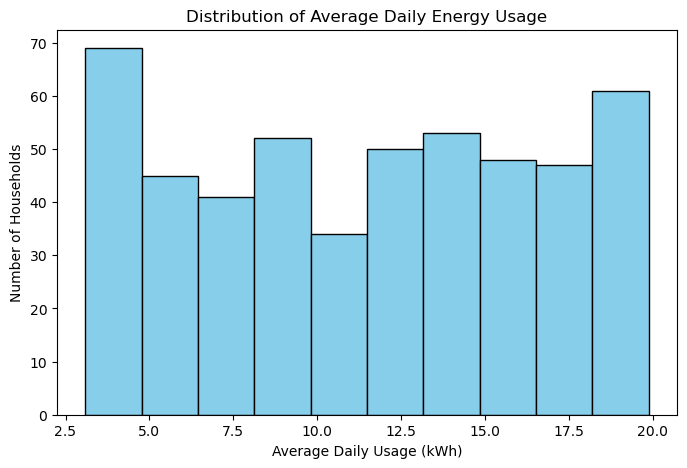

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df1['Avg_Daily_Usage_kWh'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Average Daily Energy Usage")
plt.xlabel("Average Daily Usage (kWh)")
plt.ylabel("Number of Households")
plt.show()

# Representing the correlation of data values Graphichally

<Axes: >

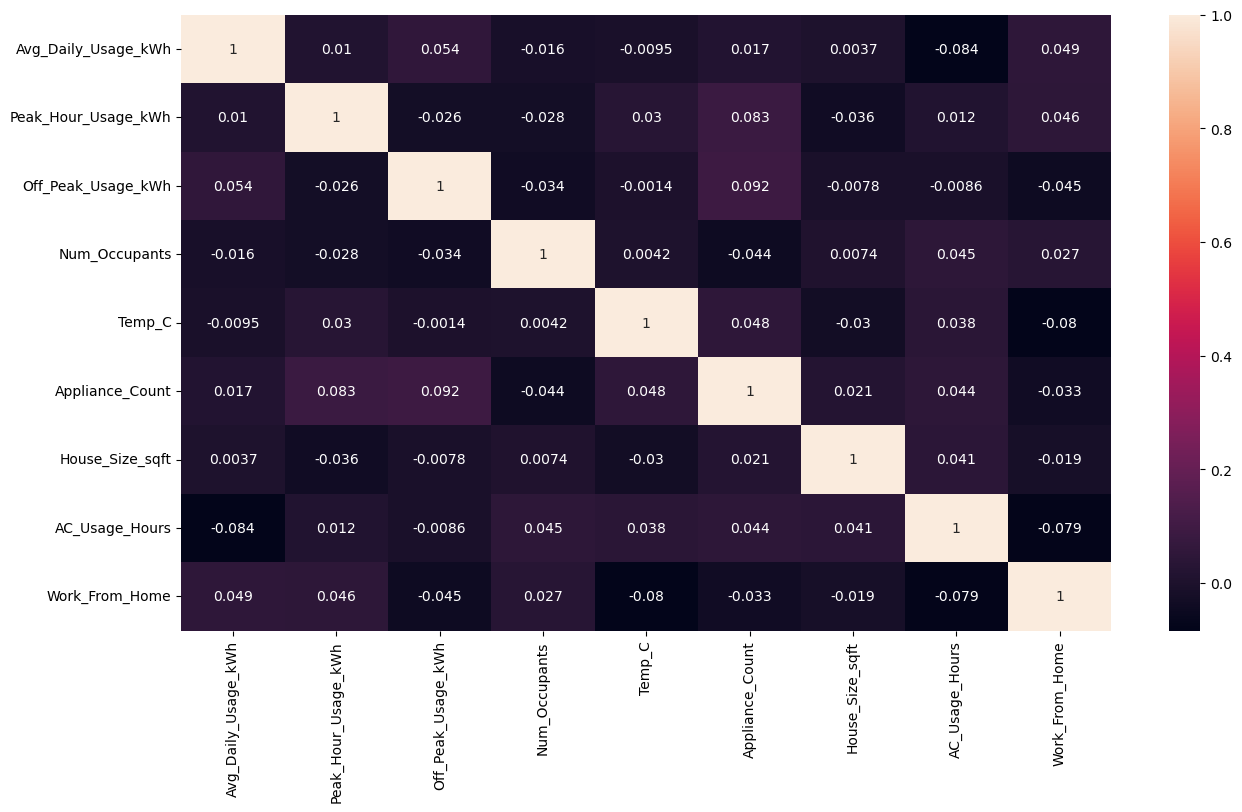

In [29]:
plt.figure(figsize=(15,8))
sns.heatmap(df1.select_dtypes(['number']).corr(),annot=True)

### Converting Categorical Values Into Numerical Values

In [13]:
obj1=LabelEncoder()
obj2=LabelEncoder()
obj3=LabelEncoder()
obj4=LabelEncoder()
obj5=LabelEncoder()

df['Income_Level'] = obj1.fit_transform(df['Income_Level'])
df['Lighting_Type'] = obj2.fit_transform(df['Lighting_Type'])
df['Consumption_Class'] = obj3.fit_transform(df['Consumption_Class'])
df['Renewable_Source'] = obj4.fit_transform(df['Renewable_Source'])
df['Smart_Meter'] = obj5.fit_transform(df['Smart_Meter'])
df

,Avg_Daily_Usage_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh,Num_Occupants,Temp_C,Appliance_Count,Income_Level,Smart_Meter,House_Size_sqft,AC_Usage_Hours,Lighting_Type,Renewable_Source,Work_From_Home,Consumption_Class
0,9.367182,5.736213,4.406728,2,26.858403,9,2,0,2520.000000,3.740278,1,1,2,2
1,19.162143,4.520723,9.044712,6,17.848916,3,2,0,3577.000000,0.037691,0,0,3,0
2,15.443897,2.821457,13.348296,4,27.150388,6,1,0,692.000000,2.090921,1,0,2,0
3,13.177194,6.603463,11.518924,5,27.323422,4,1,1,838.000000,10.504867,0,1,3,2
4,5.652317,5.635484,12.485295,5,28.019204,4,0,1,804.000000,5.300958,1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,9.006988,1.186866,10.686766,2,32.960731,4,0,0,2349.014257,0.282390,2,1,2,2
496,12.922154,7.379852,10.053375,2,38.850828,11,2,0,1889.000000,5.155474,2,0,0,2
497,4.321489,1.526140,8.025423,5,33.034836,11,1,1,2047.000000,3.347257,2,0,2,1
498,19.564712,7.626780,6.937215,4,27.323422,8,0,1,3799.000000,1.550093,1,1,3,0


In [27]:
df

,Avg_Daily_Usage_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh,Num_Occupants,Temp_C,Appliance_Count,Income_Level,Smart_Meter,House_Size_sqft,AC_Usage_Hours,Lighting_Type,Renewable_Source,Work_From_Home,Consumption_Class
0,9.367182,5.736213,4.406728,2,26.858403,9,2,0,2520.000000,3.740278,1,1,2,2
1,19.162143,4.520723,9.044712,6,17.848916,3,2,0,3577.000000,0.037691,0,0,3,0
2,15.443897,2.821457,13.348296,4,27.150388,6,1,0,692.000000,2.090921,1,0,2,0
3,13.177194,6.603463,11.518924,5,27.323422,4,1,1,838.000000,10.504867,0,1,3,2
4,5.652317,5.635484,12.485295,5,28.019204,4,0,1,804.000000,5.300958,1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,9.006988,1.186866,10.686766,2,32.960731,4,0,0,2349.014257,0.282390,2,1,2,2
496,12.922154,7.379852,10.053375,2,38.850828,11,2,0,1889.000000,5.155474,2,0,0,2
497,4.321489,1.526140,8.025423,5,33.034836,11,1,1,2047.000000,3.347257,2,0,2,1
498,19.564712,7.626780,6.937215,4,27.323422,8,0,1,3799.000000,1.550093,1,1,3,0


### Selecting Target Value

In [14]:
features = [
    'Avg_Daily_Usage_kWh',
    'Peak_Hour_Usage_kWh',
    'Off_Peak_Usage_kWh',
    'Num_Occupants',
    'Temp_C',
    'Appliance_Count',
    'Income_Level',
    'Smart_Meter',
    'House_Size_sqft',
    'AC_Usage_Hours',
    'Lighting_Type',
    'Renewable_Source',
    'Work_From_Home'
]
x = df[features]
y = df['Consumption_Class']


In [15]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

### Model Fitting

In [16]:
lr = LogisticRegression(max_iter=200)
lr.fit(xtrain, ytrain)



C:\Users\kjang\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

In [17]:
ypred_lr = lr.predict(xtest)
lr_train = lr.score(xtrain, ytrain)
lr_test = lr.score(xtest, ytest)


In [18]:
print("Training Accuracy:", lr_train)
print("Testing Accuracy:", lr_test)
print("LR Accuracy:", accuracy_score(ytest, ypred_lr))
print("\nClassification Report:\n", classification_report(ytest, ypred_lr))

Training Accuracy: 0.85
Testing Accuracy: 0.8
LR Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.79      0.77        34
           1       0.96      0.88      0.92        26
           2       0.75      0.75      0.75        40

    accuracy                           0.80       100
   macro avg       0.82      0.81      0.81       100
weighted avg       0.80      0.80      0.80       100



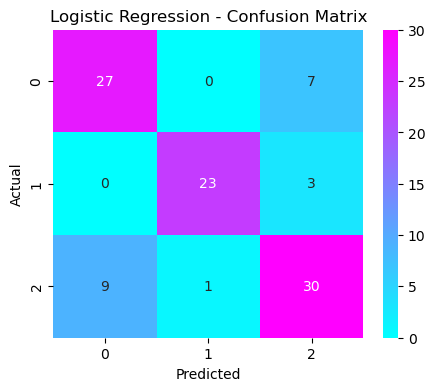

In [19]:
cm = confusion_matrix(ytest, ypred_lr)
# print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
nb= GaussianNB()
nb.fit(xtrain, ytrain)

GaussianNB()

In [28]:
ypred_nb = nb.predict(xtest)
nb_train = nb.score(xtrain, ytrain)
nb_test = nb.score(xtest, ytest)

In [29]:

print("Training Accuracy:", nb_train)
print("Testing Accuracy:", nb_test)
print("Accuracy:", accuracy_score(ytest, ypred_nb))
print("\nClassification Report:\n", classification_report(ytest, ypred_nb))


Training Accuracy: 0.9875
Testing Accuracy: 0.96
Accuracy: 0.96

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        34
           1       1.00      0.92      0.96        26
           2       0.91      1.00      0.95        40

    accuracy                           0.96       100
   macro avg       0.97      0.95      0.96       100
weighted avg       0.96      0.96      0.96       100



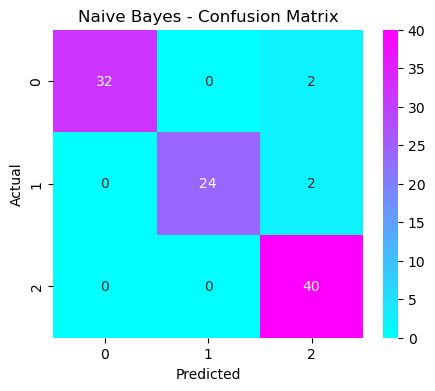

In [62]:


cm = confusion_matrix(ytest, ypred_nb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool')
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
xgb= XGBClassifier()
xgb.fit(xtrain, ytrain)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [23]:

# Predictions
ypred_xgb = xgb.predict(xtest)

# Scores
xgb_train = xgb.score(xtrain, ytrain)
xgb_test = xgb.score(xtest, ytest)



In [24]:
print("Training Accuracy:", xgb_train)
print("Testing Accuracy:", xgb_test)
print("Accuracy:", accuracy_score(ytest, ypred_xgb))
print("\nClassification Report:\n", classification_report(ytest, ypred_xgb))




Training Accuracy: 1.0
Testing Accuracy: 0.99
Accuracy: 0.99

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        34
           1       1.00      1.00      1.00        26
           2       1.00      0.97      0.99        40

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



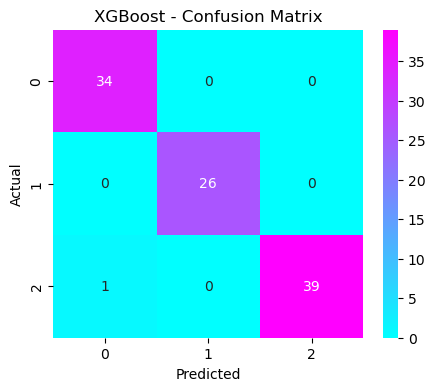

In [26]:
# Confusion Matrix
cm = confusion_matrix(ytest, ypred_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [66]:
xtrain

,Avg_Daily_Usage_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh,Num_Occupants,Temp_C,Appliance_Count,Income_Level,Smart_Meter,House_Size_sqft,AC_Usage_Hours,Lighting_Type,Renewable_Source,Work_From_Home
249,17.501161,5.181785,10.016454,6,33.768238,6,1,1,1556.0,9.522848,2,0,1
433,4.719085,4.442676,10.669235,2,19.120617,13,0,1,1544.0,0.606710,2,1,2
19,7.950895,1.628127,2.441298,3,15.317872,5,0,0,904.0,9.181924,1,0,2
322,14.223355,3.001244,13.333186,2,21.108499,6,0,0,2338.0,6.219314,1,0,2
332,3.244689,1.556428,4.969912,6,29.431243,5,1,1,1698.0,4.555401,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,9.976510,2.047503,7.151146,1,30.053641,12,0,1,3266.0,9.282633,2,1,1
270,16.759140,1.329738,11.034765,5,19.896020,11,1,0,2646.0,1.872430,0,1,1
348,9.368414,4.266463,14.839444,4,27.323422,14,1,1,2278.0,6.005728,0,1,1
435,14.916475,2.542305,2.389657,5,38.702708,14,1,1,3457.0,3.447921,0,1,1



### Representing Models Training and Testing Score Graphically

In [30]:
score = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'XGBClassifier'],
    'TrainingScores': [lr_train, nb_train, xgb_train],
    'TestingScores': [lr_test, nb_test, xgb_test]
})
score

,Model,TrainingScores,TestingScores
0,Logistic Regression,0.8500,0.80
1,Naive Bayes,0.9875,0.96
2,XGBClassifier,1.0000,0.99


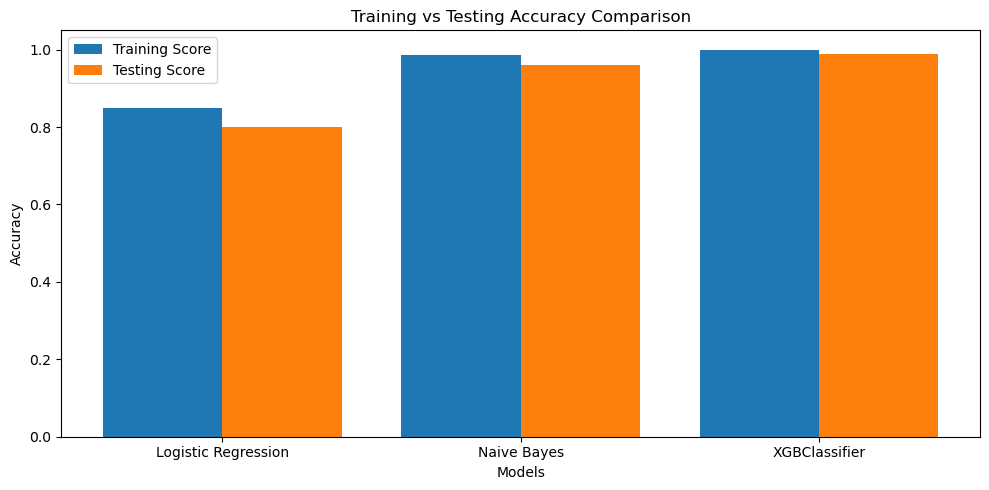

In [31]:
x = score['Model']
y = score['TrainingScores']
z = score['TestingScores']
width = 0.4
x_indices = np.arange(len(x))

plt.figure(figsize=(10, 5))
plt.bar(x_indices - width/2, y, width=width, label='Training Score')
plt.bar(x_indices + width/2, z, width=width, label='Testing Score')

plt.xticks(x_indices, x)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy Comparison')
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
  def predict_energy(avg_usage, peak_usage, off_peak_usage, occupants, temp, appliances,
                   income_level, smart_meter, house_size, ac_hours,
                   lighting_type, renewable_source, work_from_home):

    # Encode categorical inputs
    try:
        income_encoded = obj1.transform([income_level])[0]
        lighting_encoded = obj2.transform([lighting_type])[0]
        renewable_encoded = obj4.transform([renewable_source])[0]
        smart_encoded = obj5.transform([smart_meter])[0]
        wfh_encoded = obj5.transform([work_from_home])[0]
    except ValueError:
        return "Please enter valid category values (check dataset)."

    # Create input dataframe
    input_data = pd.DataFrame([[
        avg_usage,
        peak_usage,
        off_peak_usage,
        occupants,
        temp,
        appliances,
        income_encoded,
        smart_encoded,
        house_size,
        ac_hours,
        lighting_encoded,
        renewable_encoded,
        wfh_encoded
    ]], columns=features)

    # Predict
    pred = xgb.predict(input_data)[0]
    pred_label = obj3.inverse_transform([int(pred)])[0]

    return f"Predicted Consumption Class: {pred_label}"


#Gradio Interface
iface = gr.Interface(
    fn=predict_energy,
    inputs = [
    gr.Number(label="Average Daily Usage (kWh)"),
    gr.Number(label="Peak Hour Usage (kWh)"),
    gr.Number(label="Off-Peak Usage (kWh)"),
    gr.Number(label="Number of Occupants"),
    gr.Number(label="Average Temperature (°C)"),
    gr.Number(label="Appliance Count"),
    gr.Textbox(label="Income Level (e.g., Low, Medium, High)"),
    gr.Textbox(label="Smart Meter (e.g., Yes, No)"),
    gr.Number(label="House Size (sqft)"),
    gr.Number(label="AC Usage Hours per Day"),
    gr.Textbox(label="Lighting Type (e.g., LED, CFL, Incandescent)"),
    gr.Textbox(label="Renewable Source (e.g., Yes, No)"),
    gr.Textbox(label="Work From Home (e.g., Yes, No)")
],
      
    outputs=gr.Textbox(label="Prediction Result"),
    title="Energy Consumption Class Predictor",
    description="Enter household energy usage details to predict energy consumption level (Low / Medium / High)"
)

iface.launch()


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
